# Metadata Analysis
Analysis of metadata from the Bundesarchiv


# Imports

In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import json
from pathlib import Path

# Load and Prepare Data

## Load Metadata
Duration approx. 4min

In [ ]:
BASE_DIR = Path("S:/Zulassungskarten_Data/R_9346-I_Zulassungskarten")

metadata = []

for json_path in BASE_DIR.rglob("*.json"):
    try:
        with open(json_path, "r", encoding="utf-8") as f:
            data = json.load(f)

            # data["_source_folder"] = json_path.parent.name
            data["_file_name"] = json_path.name

            metadata.append(data)

    except (json.JSONDecodeError, IOError) as e:
        print(f"Error reading {json_path}: {e}")

df = pd.DataFrame(metadata)

# df

## Helper Functions

In [57]:
# Einheitliche Einstellungen für alle Diagramme
PLOT_FIGSIZE = (14, 5)
PLOT_COLORS = plt.rcParams['axes.prop_cycle'].by_key()['color']

def format_plot(ax, title, ylabel):
    ax.set_title(title, fontsize=13, pad=10)
    ax.set_xlabel('Prüfjahr', fontsize=11, labelpad=8)
    ax.set_ylabel(ylabel, fontsize=11, labelpad=8)
    ax.tick_params(axis='both', labelsize=10)
    ax.tick_params(axis='x', rotation=45)
    for label in ax.get_xticklabels():
        label.set_horizontalalignment('right')
    ax.grid(axis='x', visible=False)
    ax.grid(axis='y', linestyle='--', linewidth=0.6, alpha=0.6)
    ax.set_axisbelow(True)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

def finish_plot(fig, with_legend=False):
    for ax in fig.axes:
        for label in ax.get_xticklabels():
            label.set_rotation(45)
            label.set_horizontalalignment('right')
    rect = (0, 0, 0.84, 1) if with_legend else None
    fig.tight_layout(rect=rect)

def save_plts(fig, name):
    # Titel nur in der gespeicherten Version ausblenden.
    axes_titles = [(ax, ax.title.get_visible()) for ax in fig.axes]
    try:
        for ax, _ in axes_titles:
            ax.title.set_visible(False)
        fig.savefig(name, dpi=300)
    finally:
        for ax, visible in axes_titles:
            ax.title.set_visible(visible)

## Prepare Data

In [58]:
# Parse German dates and extract the examination year.
df['Prüfdatum_parsed'] = pd.to_datetime(
    df['Prüfdatum'],
    dayfirst=True,
    errors='coerce',
)

df['Jahr'] = df['Prüfdatum_parsed'].dt.year.astype('Int64')


df['Prüfnummer'] = pd.to_numeric(df['Prüfnummer'], errors='coerce')

df = df.sort_values(by='Prüfnummer')


### Correct Known Errors

In [59]:
df.loc[df["Jahr"].eq(1917), ["_file_name", "Jahr", "Prüfdatum", "Prüfdatum_parsed"]]

,_file_name,Jahr,Prüfdatum,Prüfdatum_parsed
19196,R 9346-I_27293.json,1917,16.1.1917,1917-01-16
19256,R 9346-I_27347.json,1917,27.1.1917,1917-01-27
19274,R 9346-I_27363.json,1917,16.2.1917,1917-02-16


In [60]:
df.loc[df["_file_name"] == "R 9346-I_27347.json", "Jahr"] = 1937
df.loc[df["_file_name"] == "R 9346-I_27363.json", "Jahr"] = 1937
df.loc[df["_file_name"] == "R 9346-I_27293.json", "Jahr"] = 1937

## Inspect Data

In [61]:
with pd.option_context("display.max_columns", None):
    display(df)

,Titel_und_Signatur,Bemerkung,Prüfnummer,Prüfdatum,Antragsteller,Produktion,Land,Filmart,Stumm-/Tonfilm,Länge (in Meter),Entscheidung,Unterlagenart,Benutzungsort,_file_name,Vorführungsbeschränkung,Ort des Prüfdatums,Prüfdatum_parsed,Jahr
0,R 9346-I/1\nDie Wölfin.\n1920 - 1945,nach Kürzung 1480 m,2.0,24.6.1920,"Solar-Film-Ges., Berlin","Solar-Film-Ges., Berlin",Deutschland,Puppenfilm,Stummfilm,1485,Jugendverbot,Zulassungskarte,Berlin-Lichterfelde,R 9346-I_1.json,NaN,NaN,1920-06-24,1920
11095,R 9346-I/2\nDie Spieler\n1920 - 1945,NaN,7.0,25.6.1920,"Asslan-Film Continental, Berlin","Asslan-Film Continental, Berlin",Deutschland,Spielfilm,Stummfilm,2379,Jugendverbot,Zulassungskarte,Berlin-Lichterfelde,R 9346-I_2.json,NaN,NaN,1920-06-25,1920
22200,R 9346-I/3\nSowas kommt von Sowas\n1920 - 1945,NaN,9.0,24.6.1920,"Karfiol-Film, Berlin","Karfiol-Film, Berlin",Deutschland,Spielfilm,Stummfilm,505,Jugendverbot,Zulassungskarte,Berlin-Lichterfelde,R 9346-I_3.json,NaN,NaN,1920-06-24,1920
29603,R 9346-I/4\nDer Gefangene. (Sklaven des XX. Ja...,LF260322: Durch Blut und Eisen,11.0,9.7.1920,"Kowo Gesellschaft, Berlin","Kowo Gesellschaft, Berlin",Deutschland,Spielfilm,Stummfilm,1833,Jugendverbot,Zulassungskarte,Berlin-Lichterfelde,R 9346-I_4.json,NaN,NaN,1920-07-09,1920
30707,R 9346-I/5\nDie entfesselte Menschheit\n1920 -...,NaN,20.0,29.6.1920,"Nivo-Film-Comp. GmbH, Berlin","Nivo-Film-Comp. GmbH, Berlin",Deutschland,Spielfilm,Stummfilm,2453,Jugendverbot,Zulassungskarte,Berlin-Lichterfelde,R 9346-I_5.json,NaN,NaN,1920-06-29,1920
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29122,R 9346-I/36536\nDrei ehrliche Banditen.,Originalquelle Zulassungskarte unvollständig O...,NaN,NaN,Deutsche Vereinsfilm AG,Fox-Film Corporation,USA,Spielfilm,Stummfilm,NaN,NaN,Zulassungskarte,Berlin-Lichterfelde,R 9346-I_36487.json,NaN,NaN,NaT,<NA>
29132,R 9346-I/36536\nDrei ehrliche Banditen.,Originalquelle Zulassungskarte unvollständig O...,NaN,NaN,Deutsche Vereinsfilm AG,Fox-Film Corporation,USA,Spielfilm,Stummfilm,NaN,NaN,Zulassungskarte,Berlin-Lichterfelde,R 9346-I_36536.json,NaN,NaN,NaT,<NA>
29135,R 9346-I/36539\nDie Macht der Versuchung.\n192...,Originalquelle Zulassungskarte unvollständig (...,NaN,NaN,Projektions-AG Union (PAGU),Projektions-AG Union (PAGU),Deutschland,Spielfilm,Stummfilm,NaN,NaN,Zulassungskarte,Berlin-Lichterfelde,R 9346-I_36539.json,NaN,NaN,NaT,<NA>
29216,R 9346-I/36611\nAlgol (Der Tragödie der Macht....,"nur 1 Blatt, ohne Prüfnummer",NaN,NaN,Universum-Film Aktiengesellschaft,Universum-Film Aktiengesellschaft,Deutschland,Spielfilm,Stummfilm,2144,NaN,Zulassungskarte,Berlin-Lichterfelde,R 9346-I_36611.json,NaN,NaN,NaT,<NA>


# Investigate Data Anomalies

In [63]:
gefilterter_df = df[df['Vorführungsbeschränkung'].notna()]
gefilterter_df

,Titel_und_Signatur,Bemerkung,Prüfnummer,Prüfdatum,Antragsteller,Produktion,Land,Filmart,Stumm-/Tonfilm,Länge (in Meter),Entscheidung,Unterlagenart,Benutzungsort,_file_name,Vorführungsbeschränkung,Ort des Prüfdatums,Prüfdatum_parsed,Jahr
29221,R 9346-I/36624\nSorgenkinder\n1920 - 1945,"nach Kürzung 308 m ""folgender Teil ist verbote...",1696.0,29.3.1921,NaN,Piccolo Grotesk Film-Ges.,Deutschland,Spielfilm,Stummfilm,312,Jugendverbot,Zulassungskarte,Berlin-Lichterfelde,R 9346-I_36624.json,nach Kürzung 308 m,Berlin,1921-03-29,1921
29139,R 9346-I/36542\nDer Mann ohne Namen. (Der Mill...,NaN,1929.0,16.4.1921,Projektions-AG Union (PAGU),Projektions-AG Union (PAGU),Deutschland,Spielfilm,Stummfilm,1799,Jugendverbot,Zulassungskarte,Berlin-Lichterfelde,R 9346-I_36542.json,nicht vor Jugendlichen,Berlin,1921-04-16,1921
10374,R 9346-I/1935\nMedizinische Musterrollen\n1920...,NaN,3950.0,26.9.1921,Kulturabteilung der Ufa,Kulturabteilung der Ufa,Deutschland,Kulturfilm,Stummfilm,308,nur für bestimmte Personengruppen,Zulassungskarte,Berlin-Lichterfelde,R 9346-I_1935.json,Nur mit Vortrag von approb. Arzt. Jugendliche ...,NaN,1921-09-26,1921
13574,R 9346-I/2223\nDer Zirkuskönig (4.Episode)\n19...,nach Kürzung 1556m,4354.0,7.10.1921,"Filmhaus Bruckmann & Co., Berlin","Universal-Film Manufacturing Co., New-York",Deutschland,Spielfilm,Stummfilm,1563,Jugendverbot,Zulassungskarte,Berlin-Lichterfelde,R 9346-I_2223.json,Teilverbote,Berlin,1921-10-07,1921
14696,R 9346-I/2223\nDer Zirkuskönig (4.Episode)\n19...,nach Kürzung 1556m,4354.0,7.10.1921,"Filmhaus Bruckmann & Co., Berlin","Universal-Film Manufacturing Co., New-York",Deutschland,Spielfilm,Stummfilm,1563,Jugendverbot,Zulassungskarte,Berlin-Lichterfelde,R 9346-I_2324.json,Teilverbote,Berlin,1921-10-07,1921
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29069,R 9346-I/36439\nDer laufende Berg\n1920 - 1945,NaN,60820.0,8.12.1944,"Universum-Film AG, Berlin","Universum-Film AG, Berlin",Deutschland,Spielfilm,Tonfilm,2455,Jugendfrei,Zulassungskarte,Berlin-Lichterfelde,R 9346-I_36439.json,Für Jugendveranstaltungen der Filmtheaterbesit...,NaN,1944-12-08,1944
29072,R 9346-I/36441\nU-Boote westwärts\n1920 - 1945,NaN,60827.0,13.12.1944,"Universum-Film AG, Berlin","Universum-Film AG, Berlin",Deutschland,Kulturfilm,Tonfilm,2706,Jugendfrei,Zulassungskarte,Berlin-Lichterfelde,R 9346-I_36441.json,Für Jugendveranstaltungen der Filmtheaterbesit...,NaN,1944-12-13,1944
29073,R 9346-I/36442\n...reitet für Deutschland\n192...,NaN,60828.0,14.12.1944,"Universum-Film AG, Berlin","Universum-Film AG, Berlin",Deutschland,Spielfilm,Tonfilm,2509,Jugendfrei,Zulassungskarte,Berlin-Lichterfelde,R 9346-I_36442.json,Für Jugendveranstaltungen der Filmtheaterbesit...,NaN,1944-12-14,1944
29082,R 9346-I/36450\nIne und ihr Pferd\n1920 - 1945,NaN,60856.0,29.12.1944,"Conrad Urban, Film-Vertrieb und Verleih, Berlin","Toho-Film AG, Tokyo",Japan,Spielfilm,Tonfilm,2236,Jugendfrei,Zulassungskarte,Berlin-Lichterfelde,R 9346-I_36450.json,Für Jugendveranstaltungen der Filmtheaterbesit...,NaN,1944-12-29,1944


In [64]:
ausprägungen_count = df['Vorführungsbeschränkung'].value_counts()
ausprägungen_count

#ausprägungen_count = df[df['Vorführungsbeschränkung'].notna()]

Vorführungsbeschränkung
Der Film ist zur Vorführung am Karfreitag, am Bußtag und am Heldengedenktag geeignet.                                                   83
Nach Änderungen an Zwischentiteln zugelassen                                                                                            20
Nach Entfernung von Zwischentitel zugelassen                                                                                            12
Nach Entfernung von Zwischentitel(n)                                                                                                    12
Für Jugendveranstaltungen der Filmtheaterbesitzer nicht geeignet.                                                                        9
                                                                                                                                        ..
Der Film wird zur öffentlichen Vorführung im Deutschen Reiche, auch vor Jugendlichen vom vollendeten 14. Lebensjahre ab, zugelassen.     1
Nur

In [65]:
#gefiltertes_df = df[df['Vorführungsbeschränkung'] == "Nur von Ärzten und Medizinstudierenden"]
#pd.set_option("display.max_rows")

gefiltertes_df = df[df['Vorführungsbeschränkung'] == "Nur in Veranstaltungen der Wehrmacht"]

gefiltertes_df

,Titel_und_Signatur,Bemerkung,Prüfnummer,Prüfdatum,Antragsteller,Produktion,Land,Filmart,Stumm-/Tonfilm,Länge (in Meter),Entscheidung,Unterlagenart,Benutzungsort,_file_name,Vorführungsbeschränkung,Ort des Prüfdatums,Prüfdatum_parsed,Jahr
27608,R 9346-I/34872\nHilfskreuzer auf allen Meeren\...,NaN,57207.0,16.5.1942,"Marine-Hauptfilm- u. Bildstelle, Berlin","Marine-Hauptfilm- u. Bildstelle, Berlin",Deutschland,Kulturfilm,Tonfilm,581,Jugendfrei,Zulassungskarte,Berlin-Lichterfelde,R 9346-I_34872.json,Nur in Veranstaltungen der Wehrmacht,NaN,1942-05-16,1942
28432,R 9346-I/35705\nSeegefecht bei Jan Mayen\n1920...,NaN,58745.0,17.3.1943,"Oberkommando der Kriegsmarine (AMA,M Wehr III ...","Oberkommando der Kriegsmarine (AMA,M Wehr III ...",Deutschland,Kulturfilm,Tonfilm,187,Jugendfrei,Zulassungskarte,Berlin-Lichterfelde,R 9346-I_35705.json,Nur in Veranstaltungen der Wehrmacht,NaN,1943-03-17,1943
28560,R 9346-I/35821\nHilfskreuzer-Atlantis\n1920 - ...,NaN,58973.0,11.5.1943,"Oberkommando der Kriegsmarine (AMA,M Wehr III ...","Oberkommando der Kriegsmarine (AMA,M Wehr III ...",Deutschland,Kulturfilm,Stummfilm,646,Jugendfrei,Zulassungskarte,Berlin-Lichterfelde,R 9346-I_35821.json,Nur in Veranstaltungen der Wehrmacht,NaN,1943-05-11,1943


# Statistical Analysis

## Documents per Year

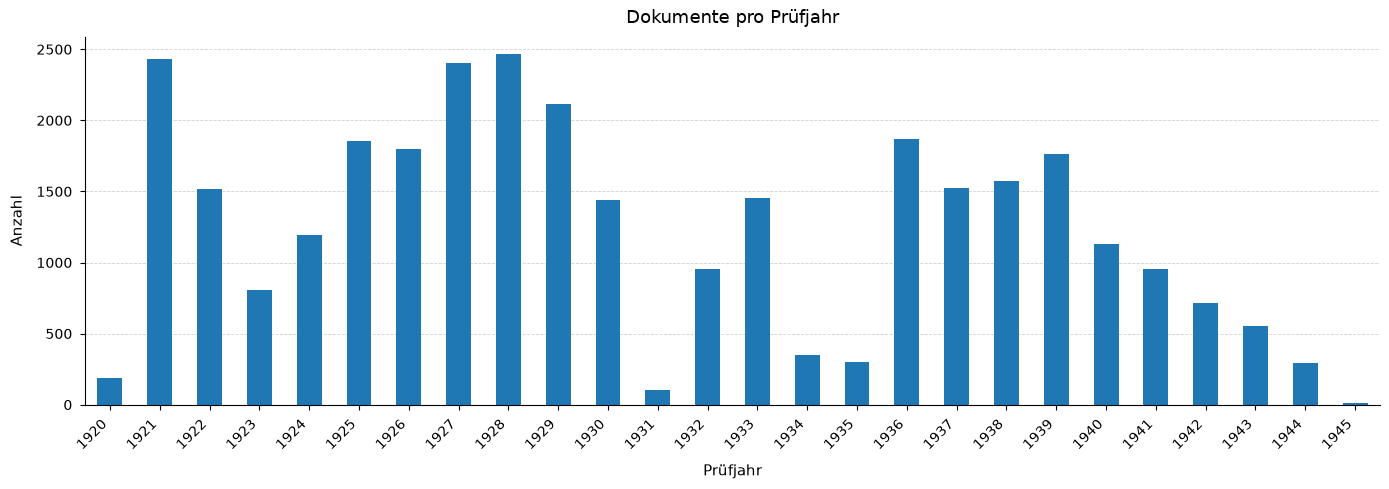

In [67]:
# data
counts_per_year = df['Jahr'].value_counts().sort_index()

# initialize Plot
fig, ax = plt.subplots(figsize=PLOT_FIGSIZE)
counts_per_year.plot(kind='bar', ax=ax, color=PLOT_COLORS[0])

format_plot(ax, 'Dokumente pro Prüfjahr', 'Anzahl')
finish_plot(fig)
save_plts(fig, "plots/metadata/documents_by_year.png")
plt.show()

## Reconstruct Missing Documents

In [68]:
summary = df.groupby('Jahr').agg(
    Eintraege_im_DF=('Prüfnummer', 'count'),
    Anfangs_Prüfnummer=('Prüfnummer', 'min'),
    End_Prüfnummer=('Prüfnummer', 'max')
).reset_index()

summary['Theoretische_Dokumente'] = summary['End_Prüfnummer'] - summary['Anfangs_Prüfnummer'] + 1
summary['Differenz_Fehlend'] = summary['Theoretische_Dokumente'] - summary['Eintraege_im_DF']

summary = summary[['Jahr', 'Anfangs_Prüfnummer', 'End_Prüfnummer', 'Theoretische_Dokumente', 'Eintraege_im_DF', 'Differenz_Fehlend']]

print(summary.to_string(index=False))

 Jahr  Anfangs_Prüfnummer  End_Prüfnummer  Theoretische_Dokumente  Eintraege_im_DF  Differenz_Fehlend
 1920                 2.0          2731.0                  2730.0              186             2544.0
 1921                22.0         23557.0                 23536.0             2435            21101.0
 1922              2491.0          6882.0                  4392.0             1515             2877.0
 1923               257.0          7986.0                  7730.0              807             6923.0
 1924              6912.0          9600.0                  2689.0             1195             1494.0
 1925              9601.0         12101.0                  2501.0             1855              646.0
 1926             11934.0         14622.0                  2689.0             1797              892.0
 1927             14536.0         18894.0                  4359.0             2402             1957.0
 1928              7049.0         21299.0                 14251.0             2464

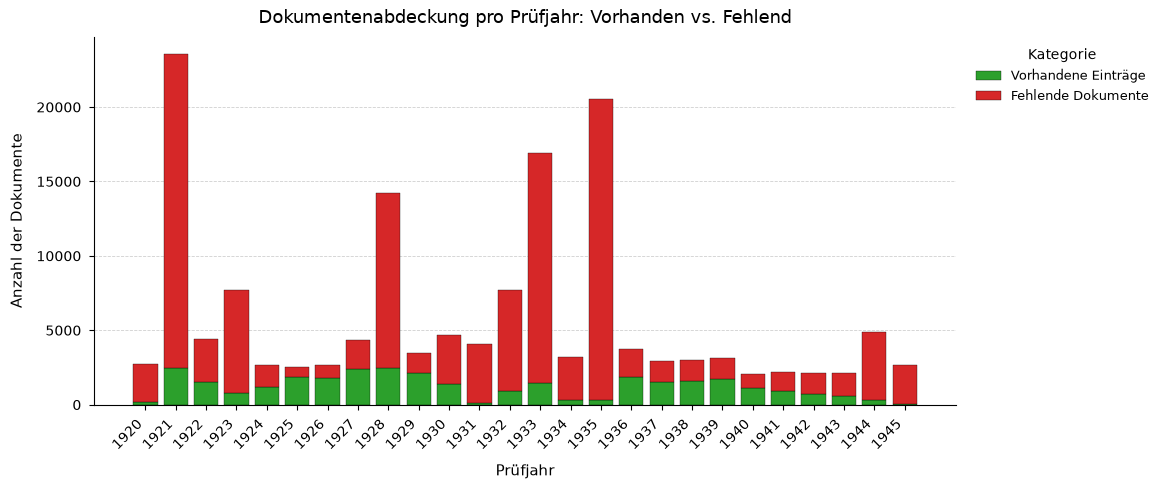

In [69]:
# data
plot_df = summary.dropna(subset=['Jahr']).copy()

# initialize Plot
fig, ax = plt.subplots(figsize=PLOT_FIGSIZE)

# bottom bar
ax.bar(
    plot_df['Jahr'], 
    plot_df['Eintraege_im_DF'], 
    label='Vorhandene Einträge', 
    color='#2ca02c',
    edgecolor='black'
)

# top bar
ax.bar(
    plot_df['Jahr'], 
    plot_df['Differenz_Fehlend'], 
    bottom=plot_df['Eintraege_im_DF'], 
    label='Fehlende Dokumente', 
    color='#d62728',
    edgecolor='black'
)

format_plot(ax, 'Dokumentenabdeckung pro Prüfjahr: Vorhanden vs. Fehlend', 'Anzahl der Dokumente')
ax.set_xticks(plot_df['Jahr'])
ax.set_xticklabels(plot_df['Jahr'], rotation=45)

ax.legend(title='Kategorie', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9, title_fontsize=10, frameon=False)
finish_plot(fig, with_legend=True)
save_plts(fig, "plots/metadata/lost_documents_by_year.png")
plt.show()

## Decisions

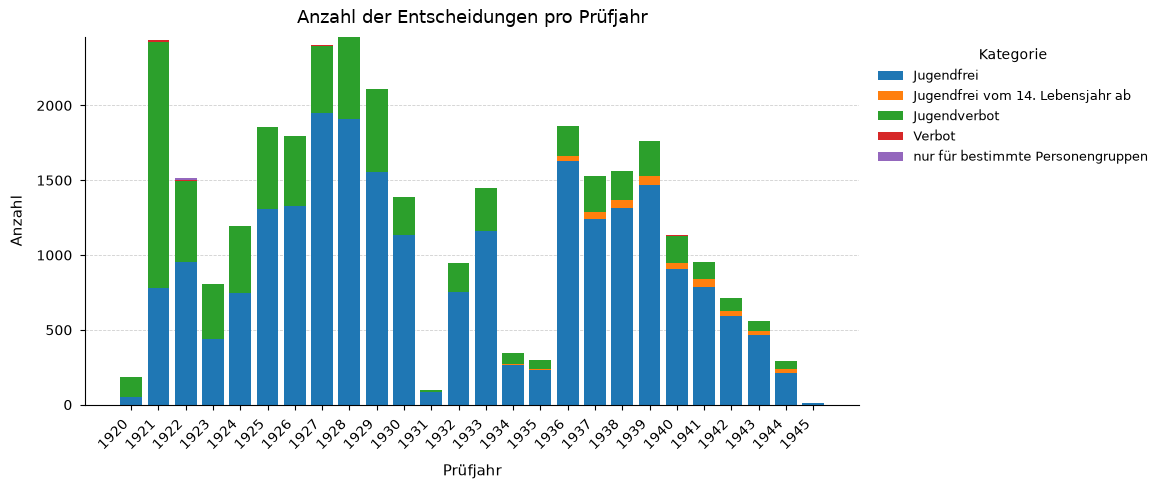

In [70]:
# data
df_decision = df.groupby(['Jahr', 'Entscheidung']).size().unstack(fill_value=0)

# initiziale Plot
fig, ax = plt.subplots(figsize=PLOT_FIGSIZE)

years = df_decision.index
bottom_values = pd.Series(0.0, index=years)

# iterate trough each columns and stack with absolute value
for i, decision in enumerate(df_decision.columns):
    ax.bar(
        years, 
        df_decision[decision], # y_value = height of current bar
        bottom=bottom_values,   # y_starting = height  whre this segment begins
        label=decision, 
        color=PLOT_COLORS[i % len(PLOT_COLORS)],
        edgecolor='black',
        linewidth=0.0
    )
    bottom_values += df_decision[decision]

format_plot(ax, 'Anzahl der Entscheidungen pro Prüfjahr', 'Anzahl')
ax.set_xticks(years)
ax.set_xticklabels(years, rotation=45)

ax.legend(title='Kategorie', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9, title_fontsize=10, frameon=False)
finish_plot(fig, with_legend=True)
save_plts(fig, "plots/metadata/decision_by_year.png")
plt.show()

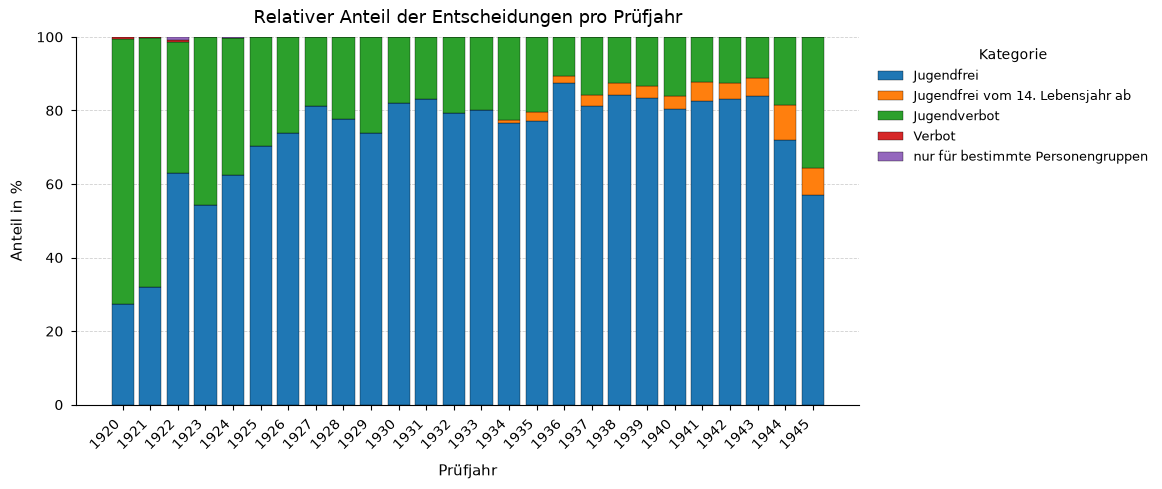

In [80]:
# data
df_grouped = df.groupby(['Jahr', 'Entscheidung']).size().unstack(fill_value=0)

plot_df = df_grouped.div(df_grouped.sum(axis=1), axis=0) * 100
jahre = plot_df.index

# initialize Plot
fig, ax = plt.subplots(figsize=PLOT_FIGSIZE)

bottom_values = pd.Series(0.0, index=jahre)

for i, entscheidung in enumerate(plot_df.columns):
    ax.bar(
        jahre, 
        plot_df[entscheidung], 
        bottom=bottom_values, 
        label=entscheidung, 
        color=PLOT_COLORS[i % len(PLOT_COLORS)],
        edgecolor='black'
    )
    bottom_values += plot_df[entscheidung]

format_plot(ax, 'Relativer Anteil der Entscheidungen pro Prüfjahr', 'Anteil in %')

ax.set_xticks(jahre)
ax.set_xticklabels(jahre, rotation=45)

ax.set_ylim(0, 100)

ax.legend(title='Kategorie', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9, title_fontsize=10, frameon=False)
finish_plot(fig, with_legend=True)
save_plts(fig, "plots/metadata/decision_relative.png")
plt.show()

In [81]:
from IPython.display import display

# Prozentuale Verteilung der Filmarten innerhalb jeder Entscheidung
decision_filmtype = df[["Jahr", "Entscheidung", "Filmart"]].copy()
decision_filmtype["Entscheidung"] = decision_filmtype["Entscheidung"].fillna("(fehlend)")
decision_filmtype["Filmart"] = decision_filmtype["Filmart"].fillna("(fehlend)")
decision_filmtype = decision_filmtype.dropna(subset=["Jahr"])

# Einmal nach Prüfjahr und einmal über den gesamten Zeitraum
counts_by_year = decision_filmtype.groupby(
    ["Jahr", "Entscheidung", "Filmart"],
    dropna=False,
).size()

decision_filmtype_percent_by_year = (
    counts_by_year
    .div(counts_by_year.groupby(level=["Jahr", "Entscheidung"]).transform("sum"))
    .mul(100)
    .unstack("Filmart", fill_value=0)
    .round(2)
)
decision_filmtype_percent_by_year.index.names = ["Prüfjahr", "Entscheidung"]

counts_total = decision_filmtype.groupby(
    ["Entscheidung", "Filmart"],
    dropna=False,
).size()

decision_filmtype_percent_total = (
    counts_total
    .div(counts_total.groupby(level="Entscheidung").transform("sum"))
    .mul(100)
    .unstack("Filmart", fill_value=0)
    .round(2)
)

print("Anteil der Filmarten innerhalb jeder Entscheidung pro Prüfjahr (in %):")
display(decision_filmtype_percent_by_year)

print("Anteil der Filmarten innerhalb jeder Entscheidung über den gesamten Zeitraum (in %):")
display(decision_filmtype_percent_total)

Anteil der Filmarten innerhalb jeder Entscheidung pro Prüfjahr (in %):


Filmart                                    (fehlend)  Dokumentarfilm  \
Prüfjahr Entscheidung                                                  
1920     Jugendfrei                             0.00            1.96   
         Jugendverbot                           0.00            0.00   
         Verbot                               100.00            0.00   
1921     Jugendfrei                             0.13            0.13   
         Jugendverbot                           0.49            0.12   
...                                              ...             ...   
1944     Jugendfrei vom 14. Lebensjahr ab       0.00            0.00   
         Jugendverbot                           0.00            0.00   
1945     Jugendfrei                             0.00           12.50   
         Jugendfrei vom 14. Lebensjahr ab       0.00            0.00   
         Jugendverbot                           0.00            0.00   

Filmart                                    Experimentalfilm  Kulturfilm  \
Prüfjahr Entscheidung                                                     
1920     Jugendfrei                                     0.0       37.25   
         Jugendverbot                                   0.0        2.24   
         Verbot                                         0.0        0.00   
1921     Jugendfrei                                     0.0       66.80   
         Jugendverbot                                   0.0        1.52   
...                                                     ...         ...   
1944     Jugendfrei vom 14. Lebensjahr ab               0.0        7.14   
         Jugendverbot                                   0.0        1.85   
1945     Jugendfrei                                     0.0       25.00   
         Jugendfrei vom 14. Lebensjahr ab               0.0        0.00   
         Jugendverbot                                   0.0        0.00   

Filmart                                    Puppenfilm  Spielfilm  Trickfilm  \
Prüfjahr Entscheidung                                                         
1920     Jugendfrei                              0.00      39.22       0.00   
         Jugendverbot                            0.75      97.01       0.00   
         Verbot                                  0.00       0.00       0.00   
1921     Jugendfrei                              0.00      26.90       0.26   
         Jugendverbot                            0.00      97.45       0.06   
...                                               ...        ...        ...   
1944     Jugendfrei vom 14. Lebensjahr ab        0.00      92.86       0.00   
         Jugendverbot                            0.00      98.15       0.00   
1945     Jugendfrei                              0.00      62.50       0.00   
         Jugendfrei vom 14. Lebensjahr ab        0.00     100.00       0.00   
         Jugendverbot                            0.00     100.00       0.00   

Filmart                                    Werbefilm  Zeichentrickfilm  
Prüfjahr Entscheidung                                                   
1920     Jugendfrei                            15.69              5.88  
         Jugendverbot                           0.00              0.00  
         Verbot                                 0.00              0.00  
1921     Jugendfrei                             5.02              0.77  
         Jugendverbot                           0.30              0.06  
...                                              ...               ...  
1944     Jugendfrei vom 14. Lebensjahr ab       0.00              0.00  
         Jugendverbot                           0.00              0.00  
1945     Jugendfrei                             0.00              0.00  
         Jugendfrei vom 14. Lebensjahr ab       0.00              0.00  
         Jugendverbot                           0.00              0.00  

[89 rows x 9 columns]

Anteil der Filmarten innerhalb jeder Entscheidung über den gesamten Zeitraum (in %):


Filmart,(fehlend),Dokumentarfilm,Experimentalfilm,Kulturfilm,Puppenfilm,Spielfilm,Trickfilm,Werbefilm,Zeichentrickfilm
Entscheidung,,,,,,,,,
(fehlend),54.26,1.06,0.00,23.40,0.00,19.15,0.00,2.13,0.00
Jugendfrei,0.03,0.20,0.01,54.82,0.02,17.76,0.09,26.45,0.62
Jugendfrei vom 14. Lebensjahr ab,0.00,0.00,0.00,5.76,0.00,92.15,0.00,2.09,0.00
Jugendverbot,0.15,0.11,0.00,3.83,0.04,95.05,0.01,0.75,0.05
Verbot,8.33,0.00,0.00,29.17,0.00,58.33,0.00,0.00,4.17
nur für bestimmte Personengruppen,0.00,0.00,0.00,87.50,0.00,6.25,0.00,6.25,0.00


## Silent and Sound Films

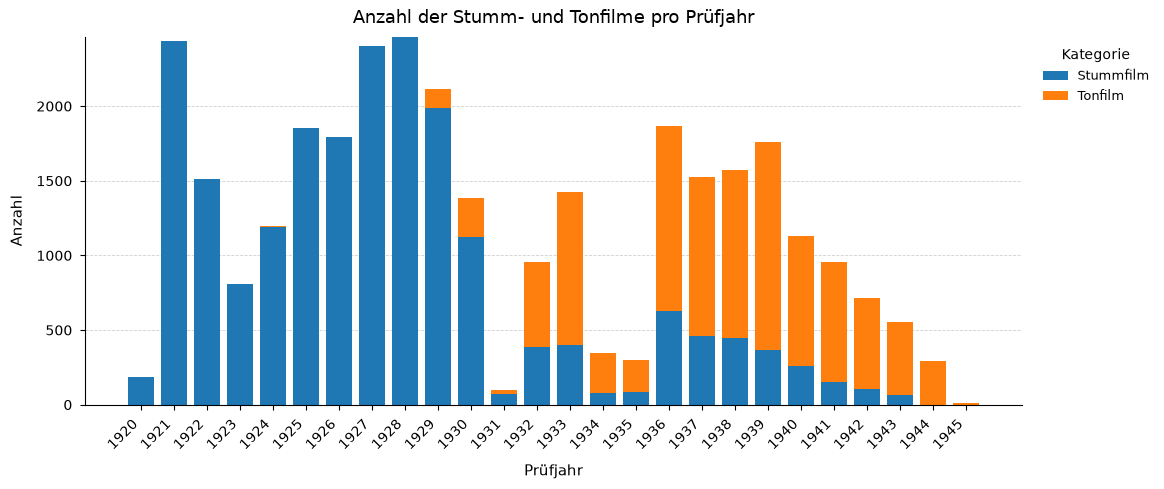

In [72]:
# data
df_silent_sound = df.groupby(['Jahr', 'Stumm-/Tonfilm']).size().unstack(fill_value=0)

# initiziale Plot
fig, ax = plt.subplots(figsize=PLOT_FIGSIZE)

years = df_silent_sound.index
bottom_values = pd.Series(0.0, index=years)

# iterate trough each columns and stack with absolute value
for i, silent_sound in enumerate(df_silent_sound.columns):
    ax.bar(
        years, 
        df_silent_sound[silent_sound], # y_value = height of current bar
        bottom=bottom_values,   # y_starting = height  whre this segment begins
        label=silent_sound, 
        color=PLOT_COLORS[i % len(PLOT_COLORS)],
        edgecolor='black',
        linewidth=0.0
    )
    bottom_values += df_silent_sound[silent_sound]

format_plot(ax, 'Anzahl der Stumm- und Tonfilme pro Prüfjahr', 'Anzahl')
ax.set_xticks(years)
ax.set_xticklabels(years, rotation=45)

ax.legend(title='Kategorie', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9, title_fontsize=10, frameon=False)
finish_plot(fig, with_legend=True)
save_plts(fig, "plots/metadata/sound_silent_by_year.png")
plt.show()

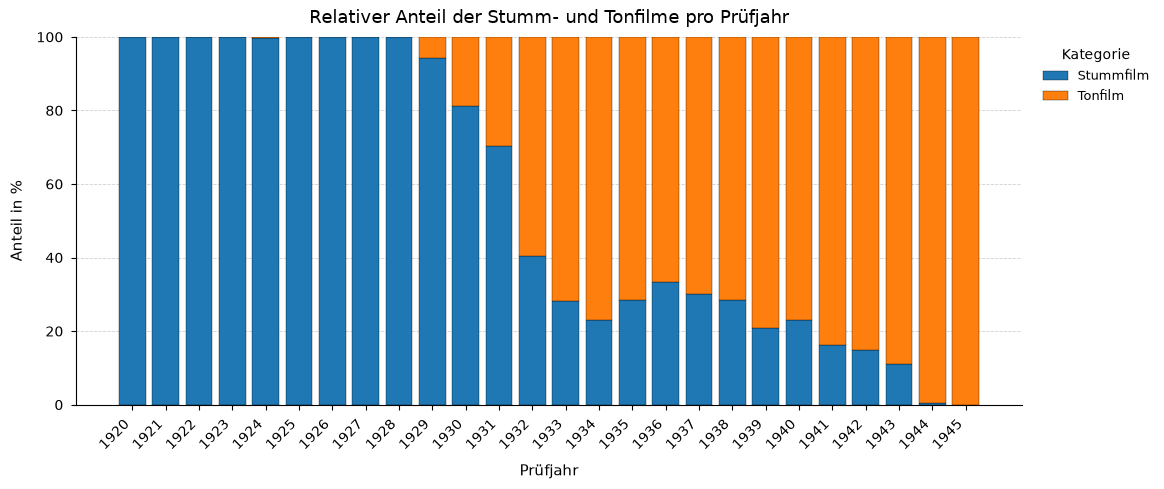

In [73]:
# data
df_grouped = df.groupby(['Jahr', 'Stumm-/Tonfilm']).size().unstack(fill_value=0)

plot_df = df_grouped.div(df_grouped.sum(axis=1), axis=0) * 100
jahre = plot_df.index

# initialize Plot
fig, ax = plt.subplots(figsize=PLOT_FIGSIZE)

bottom_values = pd.Series(0.0, index=jahre)

for i, type in enumerate(plot_df.columns):
    ax.bar(
        jahre, 
        plot_df[type], 
        bottom=bottom_values, 
        label=type, 
        color=PLOT_COLORS[i % len(PLOT_COLORS)],
        edgecolor='black'
    )
    bottom_values += plot_df[type]

format_plot(ax, 'Relativer Anteil der Stumm- und Tonfilme pro Prüfjahr', 'Anteil in %')

ax.set_xticks(jahre)
ax.set_xticklabels(jahre, rotation=45)

ax.set_ylim(0, 100)

ax.legend(title='Kategorie', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9, title_fontsize=10, frameon=False)
finish_plot(fig, with_legend=True)
save_plts(fig, "plots/metadata/sound_silent_relative.png")
plt.show()

## Film Types

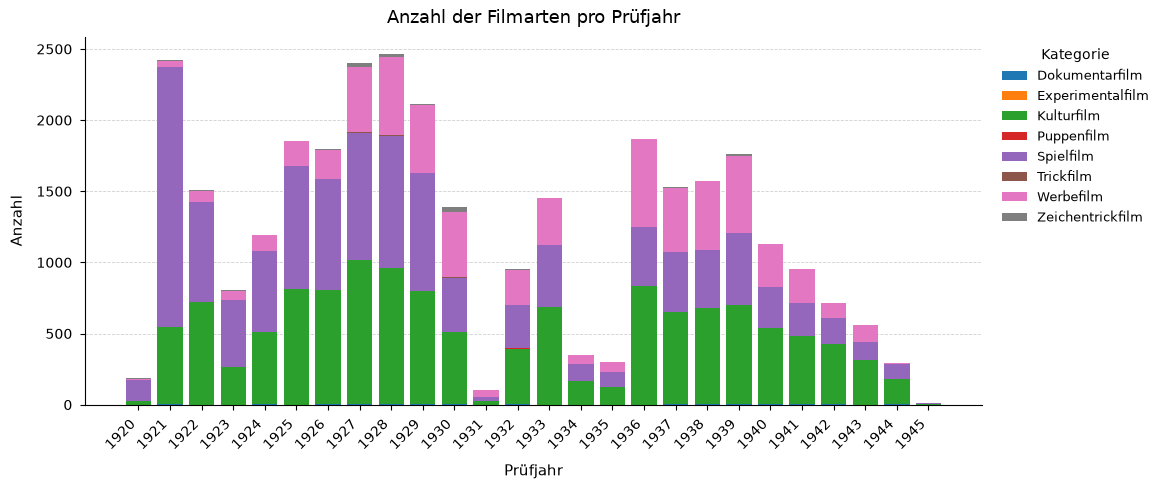

In [74]:
# data
df_filmtypes = df.groupby(['Jahr', 'Filmart']).size().unstack(fill_value=0)

# initiziale Plot
fig, ax = plt.subplots(figsize=PLOT_FIGSIZE)

years = df_filmtypes.index
bottom_values = pd.Series(0.0, index=years)

# iterate trough each columns (Filmtypes) and stack with absolute value
for i, filmtype in enumerate(df_filmtypes.columns):
    ax.bar(
        years, 
        df_filmtypes[filmtype], # y_value = height of current bar
        bottom=bottom_values,   # y_starting = height  whre this segment begins
        label=filmtype, 
        color=PLOT_COLORS[i % len(PLOT_COLORS)],
        edgecolor='black',
        linewidth=0.0
    )
    bottom_values += df_filmtypes[filmtype]

format_plot(ax, 'Anzahl der Filmarten pro Prüfjahr', 'Anzahl')
ax.set_xticks(years)
ax.set_xticklabels(years, rotation=45)

ax.legend(title='Kategorie', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9, title_fontsize=10, frameon=False)
finish_plot(fig, with_legend=True)
save_plts(fig, "plots/metadata/filmtypes_by_year.png")
plt.show()

### Relative Shares

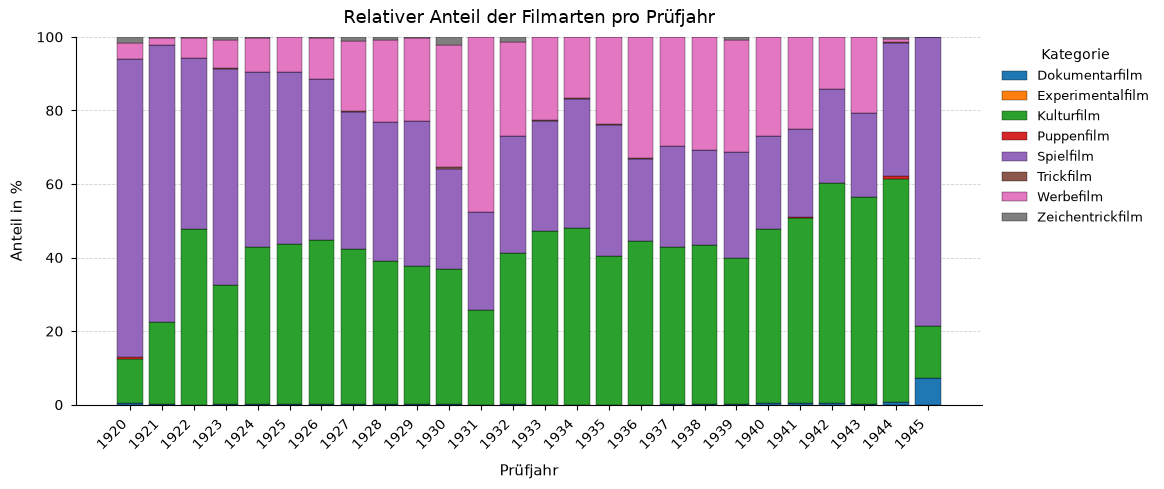

In [75]:
# data
df_grouped = df.groupby(['Jahr', 'Filmart']).size().unstack(fill_value=0)

plot_df = df_grouped.div(df_grouped.sum(axis=1), axis=0) * 100
jahre = plot_df.index

# initialize Plot
fig, ax = plt.subplots(figsize=PLOT_FIGSIZE)

bottom_values = pd.Series(0.0, index=jahre)

for i, filmart in enumerate(plot_df.columns):
    ax.bar(
        jahre, 
        plot_df[filmart], 
        bottom=bottom_values, 
        label=filmart, 
        color=PLOT_COLORS[i % len(PLOT_COLORS)],
        edgecolor='black'
    )
    bottom_values += plot_df[filmart]

format_plot(ax, 'Relativer Anteil der Filmarten pro Prüfjahr', 'Anteil in %')

ax.set_xticks(jahre)
ax.set_xticklabels(jahre, rotation=45)

ax.set_ylim(0, 100)

ax.legend(title='Kategorie', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9, title_fontsize=10, frameon=False)
finish_plot(fig, with_legend=True)
save_plts(fig, "plots/metadata/filmtypes_relative.png")
plt.show()

## Countries

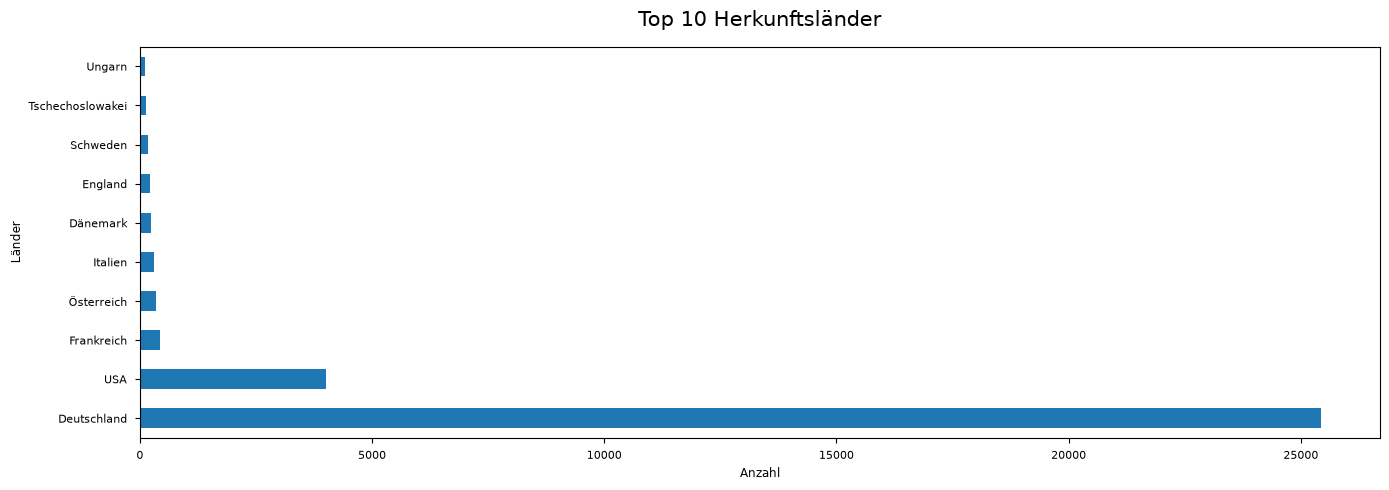

In [76]:
# data

#df_without_deutschland = df[df['Land'] != 'Deutschland']
df_countries = df.value_counts('Land')
top_countries = df_countries.head(10) 

# initiziale Plot
fig, ax = plt.subplots(figsize=(14, 5))

top_countries.plot(kind='barh', ax=ax)

# Layout/Title
ax.set_title('Top 10 Herkunftsländer', fontsize=15, pad=15)
ax.set_xlabel('Anzahl')
ax.set_ylabel('Länder')

fig.tight_layout()
plt.show()


## Production

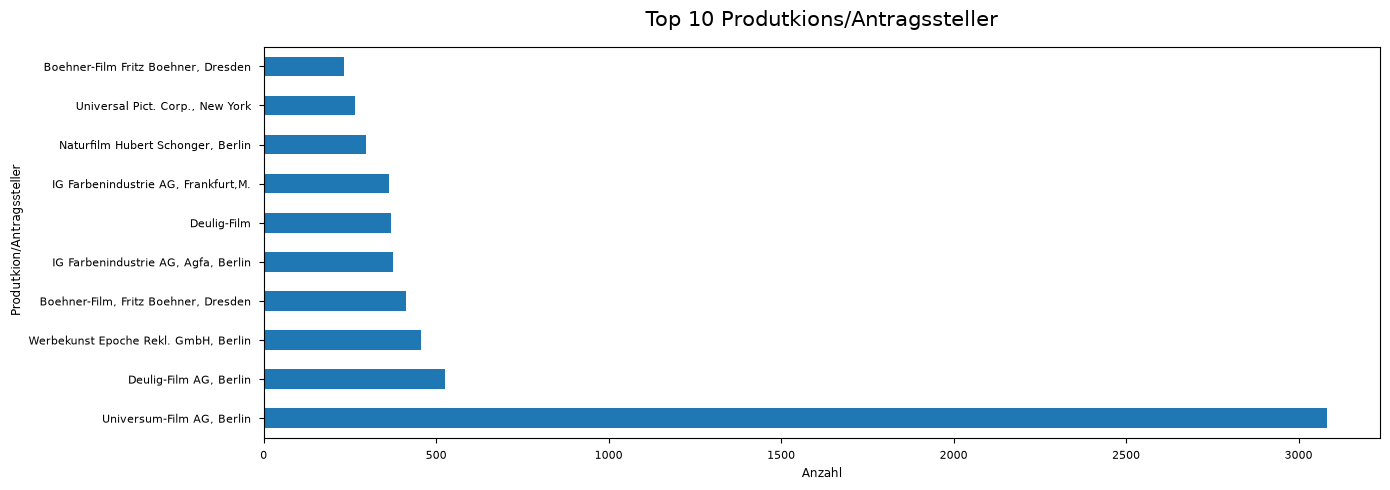

In [78]:
# data

df_producation = df.value_counts('Produktion')
top_producation = df_producation.head(10) 

# initiziale Plot
fig, ax = plt.subplots(figsize=(14, 5))

top_producation.plot(kind='barh', ax=ax)

# Layout/Title
ax.set_title('Top 10 Produtkions/Antragssteller', fontsize=15, pad=15)
ax.set_xlabel('Anzahl')
ax.set_ylabel(' Produtkion/Antragssteller')

fig.tight_layout()
plt.show()

